In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv(r"C:\Users\Jagdish singh\projects\datasets\HRDataset.csv")


In [3]:
df.columns

Index(['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID',
       'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID',
       'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB',
       'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc',
       'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus',
       'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource',
       'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction',
       'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30',
       'Absences'],
      dtype='object')

In [ ]:
df_copy=df.copy()

In [4]:
df.shape

(311, 36)

In [5]:
df.dtypes

Employee_Name                  object
EmpID                           int64
MarriedID                       int64
MaritalStatusID                 int64
GenderID                        int64
EmpStatusID                     int64
DeptID                          int64
PerfScoreID                     int64
FromDiversityJobFairID          int64
Salary                          int64
Termd                           int64
PositionID                      int64
Position                       object
State                          object
Zip                             int64
DOB                            object
Sex                            object
MaritalDesc                    object
CitizenDesc                    object
HispanicLatino                 object
RaceDesc                       object
DateofHire                     object
DateofTermination              object
TermReason                     object
EmploymentStatus               object
Department                     object
ManagerName 

In [8]:
df.isnull().sum().reset_index(name='count')

,index,count
0,Employee_Name,0
1,EmpID,0
2,MarriedID,0
3,MaritalStatusID,0
4,GenderID,0
5,EmpStatusID,0
6,DeptID,0
7,PerfScoreID,0
8,FromDiversityJobFairID,0
9,Salary,0


In [9]:
df.DateofTermination

0            NaN
1      6/16/2016
2      9/24/2012
3            NaN
4       9/6/2016
         ...    
306          NaN
307    9/29/2015
308          NaN
309          NaN
310          NaN
Name: DateofTermination, Length: 311, dtype: object

In [10]:
df["DateofTermination"].fillna("0",inplace=True)
df[df["DateofTermination"] !=0]

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,"Woodson, Jason",10135,0,0,1,1,5,3,0,65893,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,4.07,4,0,2/28/2019,0,13
307,"Ybarra, Catherine",10301,0,0,0,5,5,1,0,48513,...,Brannon Miller,12.0,Google Search,PIP,3.20,2,0,9/2/2015,5,4
308,"Zamora, Jennifer",10010,0,0,0,1,3,4,0,220450,...,Janet King,2.0,Employee Referral,Exceeds,4.60,5,6,2/21/2019,0,16
309,"Zhou, Julia",10043,0,0,0,1,3,3,0,89292,...,Simon Roup,4.0,Employee Referral,Fully Meets,5.00,3,5,2/1/2019,0,11


In [11]:
df["DateofTermination"] = pd.to_numeric(df["DateofTermination"], errors="coerce")
terminated_df = df[df["DateofTermination"].notna() & (df["DateofTermination"] != 0)]
terminated_df

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences


In [12]:
terminated_df = df[df["DateofTermination"].notna()]
terminated_df


,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
5,"Anderson, Linda",10002,0,0,0,1,5,4,0,57568,...,Amy Dunn,11.0,LinkedIn,Exceeds,5.00,5,0,1/7/2019,0,15
6,"Andreola, Colby",10194,0,0,0,1,4,3,0,95660,...,Alex Sweetwater,10.0,LinkedIn,Fully Meets,3.04,3,4,1/2/2019,0,19
7,"Athwal, Sam",10062,0,4,1,1,5,3,0,59365,...,Ketsia Liebig,19.0,Employee Referral,Fully Meets,5.00,4,0,2/25/2019,0,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305,"Wolk, Hang T",10174,0,0,0,1,5,3,0,60446,...,David Stanley,14.0,LinkedIn,Fully Meets,3.40,4,0,2/21/2019,0,14
306,"Woodson, Jason",10135,0,0,1,1,5,3,0,65893,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,4.07,4,0,2/28/2019,0,13
308,"Zamora, Jennifer",10010,0,0,0,1,3,4,0,220450,...,Janet King,2.0,Employee Referral,Exceeds,4.60,5,6,2/21/2019,0,16
309,"Zhou, Julia",10043,0,0,0,1,3,3,0,89292,...,Simon Roup,4.0,Employee Referral,Fully Meets,5.00,3,5,2/1/2019,0,11


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
 df.columns

Index(['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID',
       'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID',
       'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB',
       'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc',
       'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus',
       'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource',
       'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction',
       'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30',
       'Absences'],
      dtype='object')

In [20]:
df.PerformanceScore
x=df.groupby('PerformanceScore').size()#.to_frame(name='count')
x

PerformanceScore
Exceeds               37
Fully Meets          243
Needs Improvement     18
PIP                   13
dtype: int64

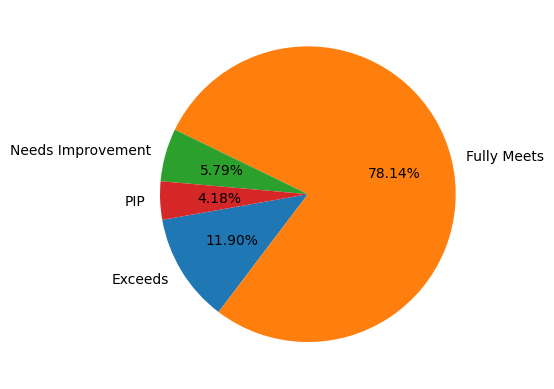

In [25]:
plt.pie(x,autopct='%1.2f%%',labels=x.index,startangle=190)
plt.show()

In [ ]:
# employee who needs special attention
#performace improvement plan 

In [26]:
df.PerformanceScore.unique()

array(['Exceeds', 'Fully Meets', 'Needs Improvement', 'PIP'], dtype=object)

In [28]:
df.groupby("PerformanceScore").size()

PerformanceScore
Exceeds               37
Fully Meets          243
Needs Improvement     18
PIP                   13
dtype: int64

In [29]:
df[df["PerformanceScore"]=="PIP"]

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
67,"Delarge, Alex",10306,0,0,1,1,6,1,0,61568,...,John Smith,17.0,Indeed,PIP,1.93,3,0,1/30/2019,6,5
69,"Desimone, Carl",10310,1,1,1,1,5,1,0,53189,...,Amy Dunn,11.0,Indeed,PIP,1.12,2,0,1/31/2019,4,9
72,"Dietrich, Jenna",10304,0,0,0,1,6,1,0,59231,...,John Smith,17.0,Website,PIP,2.30,1,0,1/29/2019,2,17
83,"Erilus, Angela",10299,0,3,0,1,5,1,0,56847,...,Michael Albert,22.0,Indeed,PIP,3.00,1,0,2/25/2019,2,5
90,"Fernandes, Nilson",10308,1,1,1,1,5,1,0,64057,...,Amy Dunn,11.0,Indeed,PIP,1.56,5,0,1/3/2019,6,15
91,"Fett, Boba",10309,0,0,1,1,3,1,0,53366,...,Peter Monroe,7.0,LinkedIn,PIP,1.20,3,6,2/4/2019,3,2
95,"Forrest, Alex",10305,1,1,1,1,6,3,0,70187,...,Lynn Daneault,21.0,Employee Referral,PIP,2.00,5,0,1/28/2019,4,7
112,"Gonzalez, Juan",10300,1,1,1,5,5,1,1,68898,...,Brannon Miller,12.0,Diversity Job Fair,PIP,3.00,3,0,3/6/2011,3,10
188,"Miller, Ned",10298,0,0,1,5,5,1,0,55800,...,Brannon Miller,12.0,LinkedIn,PIP,3.00,2,0,1/14/2013,6,6
205,"O'hare, Lynn",10303,0,0,0,4,5,1,0,52674,...,Kissy Sullivan,20.0,LinkedIn,PIP,2.33,2,0,3/9/2018,6,3


In [31]:
df.groupby([df["PerformanceScore"]=="PIP"]).size()

PerformanceScore
False    298
True      13
dtype: int64

In [32]:
df[df["PerformanceScore"]=="PIP"].Employee_Name

67           Delarge, Alex
69         Desimone, Carl 
72       Dietrich, Jenna  
83          Erilus, Angela
90     Fernandes, Nilson  
91              Fett, Boba
95           Forrest, Alex
112         Gonzalez, Juan
188            Miller, Ned
205           O'hare, Lynn
263       Sparks, Taylor  
267     Stansfield, Norman
307     Ybarra, Catherine 
Name: Employee_Name, dtype: object

In [33]:
len(df[df["PerformanceScore"]=="PIP"].Employee_Name)

13

In [34]:
df.columns

Index(['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID',
       'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID',
       'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB',
       'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc',
       'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus',
       'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource',
       'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction',
       'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30',
       'Absences'],
      dtype='object')

In [35]:
df.Absences
df.Absences.value_counts().sort_index()

Absences
1     14
2     21
3     16
4     23
5     12
6     16
7     21
8     11
9     14
10    10
11    15
12     8
13    17
14    17
15    20
16    23
17    15
18     8
19    16
20    14
Name: count, dtype: int64

In [37]:
df.Absences.value_counts(normalize=True)*100
#give percantage to each values 

Absences
4     7.395498
16    7.395498
7     6.752412
2     6.752412
15    6.430868
14    5.466238
13    5.466238
3     5.144695
19    5.144695
6     5.144695
11    4.823151
17    4.823151
1     4.501608
9     4.501608
20    4.501608
5     3.858521
8     3.536977
10    3.215434
12    2.572347
18    2.572347
Name: proportion, dtype: float64

In [48]:
df[["Employee_Name", "Absences"]].sort_values(by="Absences", ascending=False)


,Employee_Name,Absences
256,"Sloan, Constance",20
263,"Sparks, Taylor",20
155,"Kreuger, Freddy",20
121,"Guilianno, Mike",20
93,"Fitzpatrick, Michael J",20
...,...,...
207,"Onque, Jasmine",1
62,"Darson, Jene'ya",1
68,"Demita, Carla",1
71,"Dickinson, Geoff",1


In [39]:
df.MarriedID.value_counts()

MarriedID
0    187
1    124
Name: count, dtype: int64

In [41]:
df.groupby("MarriedID").size()

MarriedID
0    187
1    124
dtype: int64

In [42]:
df.columns

Index(['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID',
       'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID',
       'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB',
       'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc',
       'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus',
       'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource',
       'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction',
       'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30',
       'Absences'],
      dtype='object')

In [44]:
df.SpecialProjectsCount.sort_values(ascending=False)

61     8
299    8
70     7
109    7
42     7
      ..
50     0
51     0
52     0
53     0
304    0
Name: SpecialProjectsCount, Length: 311, dtype: int64

In [50]:
df.SpecialProjectsCount.sum()
df.SpecialProjectsCount.value_counts().reset_index().sort_values(by="SpecialProjectsCount")

,SpecialProjectsCount,count
0,0,241
8,1,1
7,2,1
5,3,3
4,4,9
2,5,21
1,6,21
3,7,12
6,8,2


In [51]:
df[df["SpecialProjectsCount"] > 0][["Employee_Name", "SpecialProjectsCount"]]


,Employee_Name,SpecialProjectsCount
1,"Ait Sidi, Karthikeyan",6
6,"Andreola, Colby",4
9,"Bacong, Alejandro",6
12,"Barbossa, Hector",5
18,"Becker, Renee",5
...,...,...
292,"Voldemort, Lord",7
298,"Wang, Charlie",7
299,"Warfield, Sarah",8
308,"Zamora, Jennifer",6


In [55]:

df[df["SpecialProjectsCount"]!=0].Employee_Name.reset_index()

,index,Employee_Name
0,1,"Ait Sidi, Karthikeyan"
1,6,"Andreola, Colby"
2,9,"Bacong, Alejandro"
3,12,"Barbossa, Hector"
4,18,"Becker, Renee"
...,...,...
65,292,"Voldemort, Lord"
66,298,"Wang, Charlie"
67,299,"Warfield, Sarah"
68,308,"Zamora, Jennifer"


In [56]:
#70- employee doesnt have special project

In [57]:
df["SpecialProjectsCount"].sort_values(ascending=False)

61     8
299    8
70     7
109    7
42     7
      ..
50     0
51     0
52     0
53     0
304    0
Name: SpecialProjectsCount, Length: 311, dtype: int64

In [ ]:
# visulaozition 

In [58]:
df[["Salary","Employee_Name"]]

,Salary,Employee_Name
0,62506,"Adinolfi, Wilson K"
1,104437,"Ait Sidi, Karthikeyan"
2,64955,"Akinkuolie, Sarah"
3,64991,"Alagbe,Trina"
4,50825,"Anderson, Carol"
...,...,...
306,65893,"Woodson, Jason"
307,48513,"Ybarra, Catherine"
308,220450,"Zamora, Jennifer"
309,89292,"Zhou, Julia"


In [60]:
x1=df.Salary.sort_values(ascending=False).head(10).reset_index(name='count')
x1

,index,count
0,150,250000
1,308,220450
2,131,180000
3,96,178000
4,55,170500
5,190,157000
6,240,150290
7,244,148999
8,243,140920
9,76,138888


In [61]:
df[["Salary","Employee_Name"]].sort_values(by="Salary",ascending=True).head(10)

,Salary,Employee_Name
310,45046,"Zima, Colleen"
140,45069,"Jacobi, Hannah"
231,45115,"Rhoads, Thomas"
176,45395,"Mahoney, Lauren"
152,45433,"Kirill, Alexandra"
216,45998,"Perry, Shakira"
159,46120,"Langton, Enrico"
74,46335,"Dobrin, Denisa S"
247,46428,"Sadki, Nore"
226,46430,"Purinton, Janine"


In [62]:
y1=df["Salary"].sort_values(ascending=True).head(10)

In [63]:
c=[1,2,3,4,5,6,7,8,9,10]

In [65]:
l=df["RecruitmentSource"].value_counts()
l

RecruitmentSource
Indeed                     87
LinkedIn                   76
Google Search              49
Employee Referral          31
Diversity Job Fair         29
CareerBuilder              23
Website                    13
Other                       2
On-line Web application     1
Name: count, dtype: int64

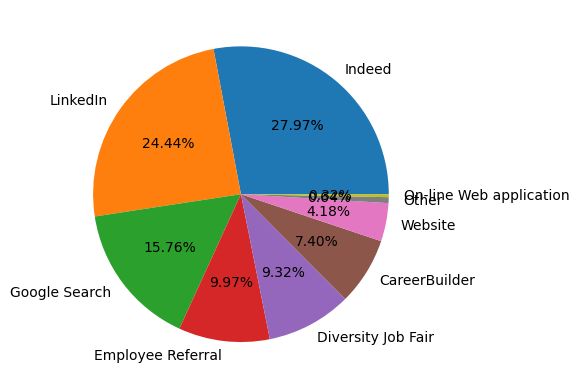

In [69]:
plt.pie(l,autopct="%1.2f%%",labels=l.index)
plt.show()

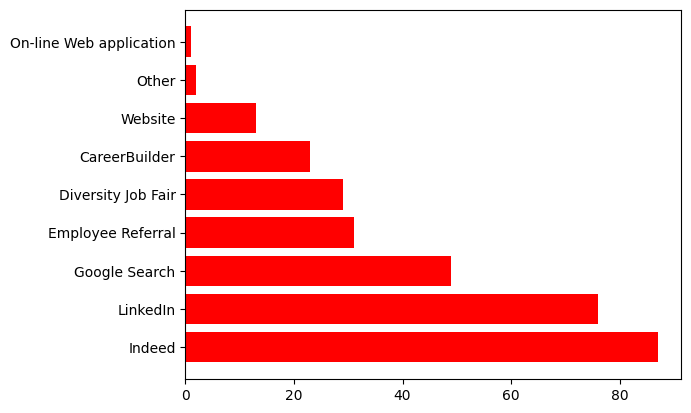

In [70]:
plt.barh( l.index,l,color='r')
plt.show()

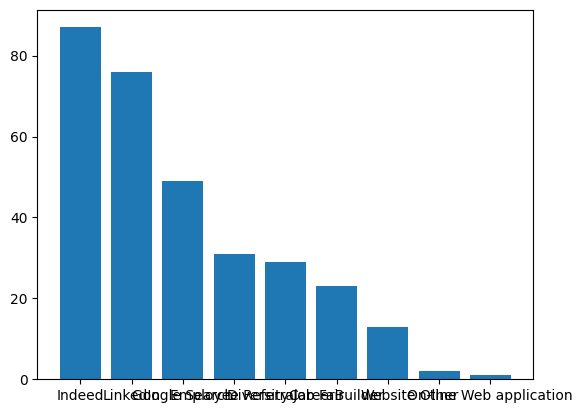

In [ ]:
x=[1,2,3,4,5,6,7,8,9,10]
plt.bar( l.index , l.values)
plt.show()

In [72]:
z=df.PerformanceScore.value_counts()
z

PerformanceScore
Fully Meets          243
Exceeds               37
Needs Improvement     18
PIP                   13
Name: count, dtype: int64

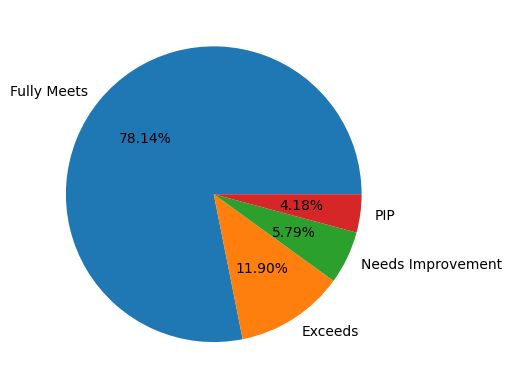

In [74]:
plt.pie(z,autopct="%1.2f%%",labels=z.index)
plt.show()

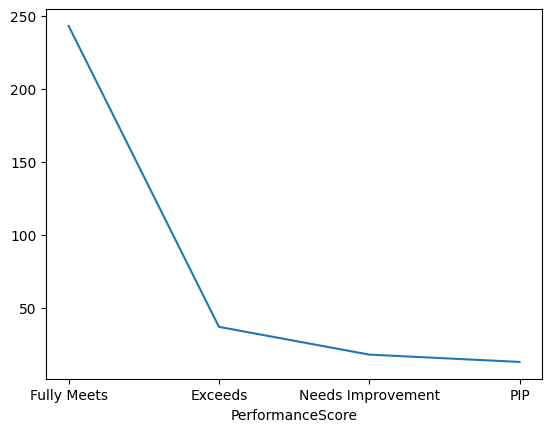

In [75]:
sns.lineplot(x=z.index,y=z.values)
plt.show()

In [ ]:
#insights
 #genrally trend is increasing avg score 50-250

In [77]:
df.EmpSatisfaction.reset_index()

,index,EmpSatisfaction
0,0,5
1,1,3
2,2,3
3,3,5
4,4,4
...,...,...
306,306,4
307,307,2
308,308,5
309,309,3


In [78]:
z1=df["EmpSatisfaction"].value_counts().sort_index(ascending=True)
z1

EmpSatisfaction
1      2
2      9
3    108
4     94
5     98
Name: count, dtype: int64

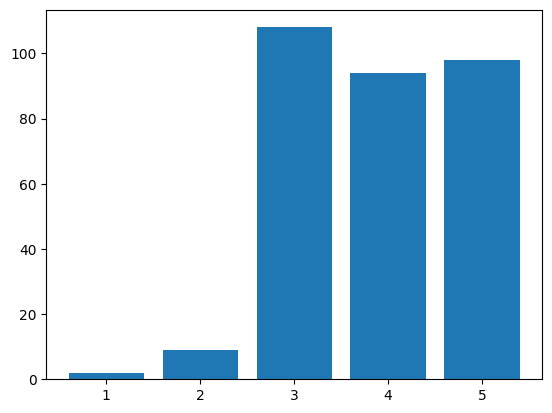

In [79]:
plt.bar(z1.index,z1.values)
plt.show()

In [81]:
#outliers in salary
df.Department.value_counts()

Department
Production              209
IT/IS                    50
Sales                    31
Software Engineering     11
Admin Offices             9
Executive Office          1
Name: count, dtype: int64

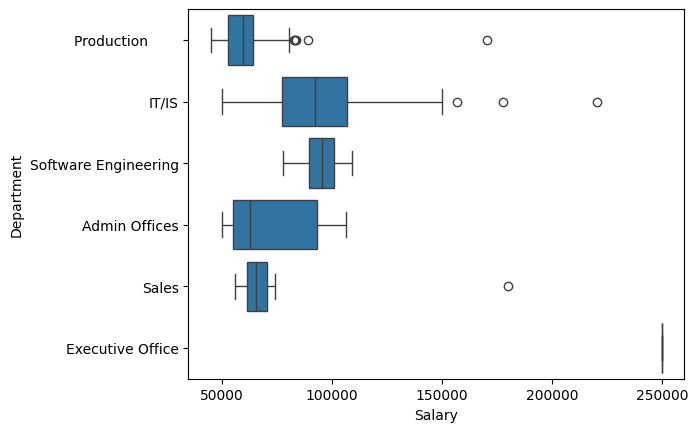

In [84]:
x2=df["Salary"]
y2=df["Department"]
sns.boxplot(x=x2,y=y2)
plt.show()


In [85]:
x3=df.Position.value_counts()
x3

Position
Production Technician I         137
Production Technician II         57
Area Sales Manager               27
Production Manager               14
Software Engineer                10
IT Support                        8
Data Analyst                      7
Database Administrator            5
Sr. Network Engineer              5
Network Engineer                  5
BI Developer                      4
Accountant I                      3
Administrative Assistant          3
Sales Manager                     3
Senior BI Developer               3
Sr. Accountant                    2
Sr. DBA                           2
IT Manager - DB                   2
Software Engineering Manager      1
Enterprise Architect              1
Director of Operations            1
BI Director                       1
IT Manager - Support              1
IT Director                       1
President & CEO                   1
Director of Sales                 1
IT Manager - Infra                1
Shared Services Man

In [87]:
y3=df.EngagementSurvey.value_counts()
y3

EngagementSurvey
5.00    56
4.50    19
4.20    17
4.30    17
4.10    16
        ..
3.11     1
2.50     1
3.42     1
4.07     1
3.20     1
Name: count, Length: 119, dtype: int64

In [88]:
df[["EngagementSurvey","Position"]]

,EngagementSurvey,Position
0,4.60,Production Technician I
1,4.96,Sr. DBA
2,3.02,Production Technician II
3,4.84,Production Technician I
4,5.00,Production Technician I
...,...,...
306,4.07,Production Technician II
307,3.20,Production Technician I
308,4.60,CIO
309,5.00,Data Analyst


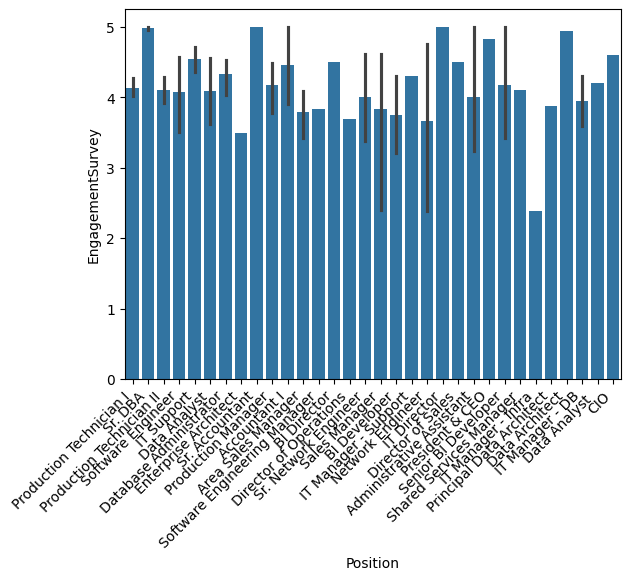

In [92]:
sns.barplot(x = 'Position' , y='EngagementSurvey', data=df)
plt.xticks(rotation=45, ha='right')
plt.show()

In [93]:
x4=df.MarriedID.value_counts()

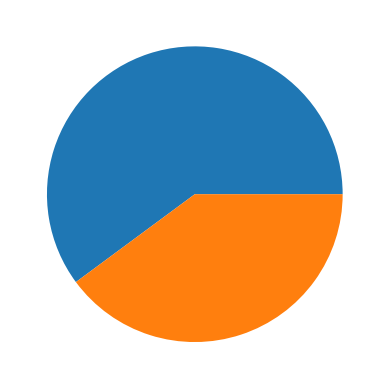

In [94]:
plt.pie(x4)
plt.show()

In [95]:
df.MaritalDesc.unique()

array(['Single', 'Married', 'Divorced', 'Widowed', 'Separated'],
      dtype=object)

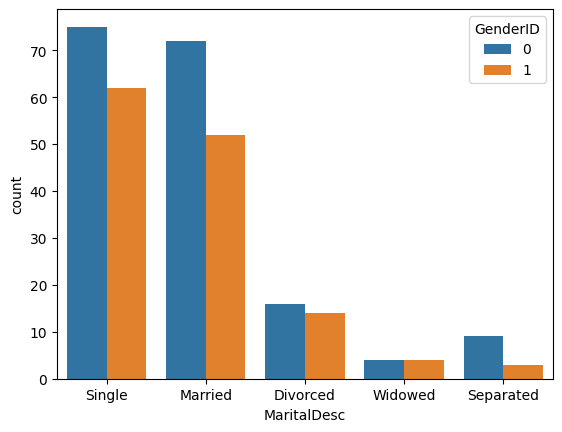

In [96]:
sns.countplot(x="MaritalDesc",hue='GenderID', data=df)
plt.show()

In [97]:
df.columns

Index(['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID',
       'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID',
       'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB',
       'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc',
       'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus',
       'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource',
       'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction',
       'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30',
       'Absences'],
      dtype='object')

In [99]:
df.EngagementSurvey.reset_index()


,index,EngagementSurvey
0,0,4.60
1,1,4.96
2,2,3.02
3,3,4.84
4,4,5.00
...,...,...
306,306,4.07
307,307,3.20
308,308,4.60
309,309,5.00


In [100]:
df.groupby('Department')['EngagementSurvey'].mean()

Department
Admin Offices           4.393333
Executive Office        4.830000
IT/IS                   4.154000
Production              4.129569
Sales                   3.818710
Software Engineering    4.061818
Name: EngagementSurvey, dtype: float64

In [ ]:
#how many empyee trminated for each psotion 

In [ ]:
df.columns

In [102]:
df.loc[df["SpecialProjectsCount"] != 0, "Employee_Name"]
#row label,column label


1      Ait Sidi, Karthikeyan   
6               Andreola, Colby
9            Bacong, Alejandro 
12             Barbossa, Hector
18                Becker, Renee
                 ...           
292             Voldemort, Lord
298               Wang, Charlie
299             Warfield, Sarah
308            Zamora, Jennifer
309                 Zhou, Julia
Name: Employee_Name, Length: 70, dtype: object

In [106]:
df.DateofTermination
df[df["DateofTermination"] !=0].groupby("Position").size()

Position
Administrative Assistant     2
Area Sales Manager           4
Data Analyst                 1
Data Analyst                 1
Database Administrator       3
Enterprise Architect         1
IT Manager - DB              1
Network Engineer             1
Principal Data Architect     1
Production Manager           5
Production Technician I     52
Production Technician II    26
Sales Manager                1
Software Engineer            4
Sr. DBA                      1
dtype: int64

In [112]:
terminated_per_position = df[df["DateofTermination"] != 0].groupby("Position").size()


In [107]:
df.PositionID
df.DateofTermination
df[["DateofTermination","PositionID"]]


,DateofTermination,PositionID
0,0.0,19
1,NaN,27
2,NaN,20
3,0.0,19
4,NaN,19
...,...,...
306,0.0,20
307,NaN,19
308,0.0,6
309,0.0,9


In [109]:
terminated_per_position = df[df["Termd"] == 1].groupby("Position").size().sort_values(ascending=False)


In [113]:
df[df["DateofTermination"] != 0].groupby("Position").size()


Position
Administrative Assistant     2
Area Sales Manager           4
Data Analyst                 1
Data Analyst                 1
Database Administrator       3
Enterprise Architect         1
IT Manager - DB              1
Network Engineer             1
Principal Data Architect     1
Production Manager           5
Production Technician I     52
Production Technician II    26
Sales Manager                1
Software Engineer            4
Sr. DBA                      1
dtype: int64

In [ ]:
# median salary of male and female empyess
df.columns

In [114]:
df.Salary
df.Sex.value_counts()

Sex
F     176
M     135
Name: count, dtype: int64

In [116]:
df.groupby("Sex")["Salary"].median().reset_index()

,Sex,Salary
0,F,62066.5
1,M,63353.0


In [117]:
# total absecners and avg engamgemnt score for each department
df["EngagementSurvey"].mean()


np.float64(4.11)

In [118]:
df.groupby('Department')["EngagementSurvey"].sum()

Department
Admin Offices            39.54
Executive Office          4.83
IT/IS                   207.70
Production              863.08
Sales                   118.38
Software Engineering     44.68
Name: EngagementSurvey, dtype: float64

In [119]:
df.groupby('Department')['EngagementSurvey'].mean()


Department
Admin Offices           4.393333
Executive Office        4.830000
IT/IS                   4.154000
Production              4.129569
Sales                   3.818710
Software Engineering    4.061818
Name: EngagementSurvey, dtype: float64

In [122]:
df.groupby('Department').agg(
    avg_absences=('Absences', 'mean'),
    total_absences=('Absences', 'sum')
)


,avg_absences,total_absences
Department,,
Admin Offices,8.666667,78
Executive Office,10.000000,10
IT/IS,10.440000,522
Production,10.143541,2120
Sales,11.548387,358
Software Engineering,8.727273,96


In [ ]:
#.agg() (aggregate) is used after groupby() to apply one or multiple aggregation functions (sum, mean, count, max, min, etc.) on one or more columns.
#df.groupby('GroupColumn').agg(
  #  new_column_name = ('existing_column', 'aggregation_function')

In [124]:
df.groupby('Department')['Absences'].sum()
df.groupby('Department')['Absences'].mean().reset_index(name="mean_absences")


,Department,mean_absences
0,Admin Offices,8.666667
1,Executive Office,10.000000
2,IT/IS,10.440000
3,Production,10.143541
4,Sales,11.548387
5,Software Engineering,8.727273


In [ ]:
#toatls no ofspecial projects and avg absecnces for employee in each gender

In [125]:
df.groupby('Sex').agg(
    { 'SpecialProjectsCount': 'sum',
     'Absences':'mean'
     })


,SpecialProjectsCount,Absences
Sex,,
F,183,10.261364
M,196,10.207407


In [ ]:
df.columns

In [ ]:
#maximum salary andd minmum days late in last 30 days for employess in each psotion 

In [126]:
df.groupby('Position').agg(
    {
        'Salary':'max'
    }
)

,Salary
Position,
Accountant I,64520
Administrative Assistant,55000
Area Sales Manager,74326
BI Developer,99020
BI Director,110929
CIO,220450
Data Analyst,93554
Data Analyst,88527
Data Architect,150290


In [ ]:
df.columns

In [ ]:
#how mnay terminated empyoees were ther in each department 


In [ ]:
df[df["DateofTermination"] !=0 ].groupby('Position').size()


In [ ]:
df.columns

In [128]:
df.loc[df["DateofTermination"] !=0,["Department"]].value_counts().reset_index()


,Department,count
0,Production,83
1,IT/IS,10
2,Sales,5
3,Software Engineering,4
4,Admin Offices,2


In [132]:
df[df["DateofTermination"]!=0].groupby('Department').size().sort_values().reset_index()

,Department,0
0,Admin Offices,2
1,Software Engineering,4
2,Sales,5
3,IT/IS,10
4,Production,83


In [133]:
df['Terminated'] = df['DateofTermination'] != 0
terminated_emp = df[df['Terminated']].groupby('Department').size()
terminated_emp


Department
Admin Offices            2
IT/IS                   10
Production              83
Sales                    5
Software Engineering     4
dtype: int64

In [134]:
active_emp = df[~df['Terminated']].groupby('Department').size()
active_emp

Department
Admin Offices             7
Executive Office          1
IT/IS                    40
Production              126
Sales                    26
Software Engineering      7
dtype: int64

In [135]:
total_emp= df.groupby("Department").size()
total_emp

Department
Admin Offices             9
Executive Office          1
IT/IS                    50
Production              209
Sales                    31
Software Engineering     11
dtype: int64

In [136]:
df.loc[df["DateofTermination"] != 0, ["Department"]].value_counts()


Department          
Production              83
IT/IS                   10
Sales                    5
Software Engineering     4
Admin Offices            2
Name: count, dtype: int64

In [137]:
summary = df.groupby('Department').agg(
    total_employees=('EmpID', 'count'),
    terminated_employees=('DateofTermination', lambda x: (x != 0).sum())
)

summary['active_employees'] = (
    summary['total_employees'] - summary['terminated_employees']
)

summary


,total_employees,terminated_employees,active_employees
Department,,,
Admin Offices,9,2,7
Executive Office,1,0,1
IT/IS,50,10,40
Production,209,83,126
Sales,31,5,26
Software Engineering,11,4,7
